In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
def f(x):
    return 3*x**2 - 4*x + 5

In [5]:
f(3)

20

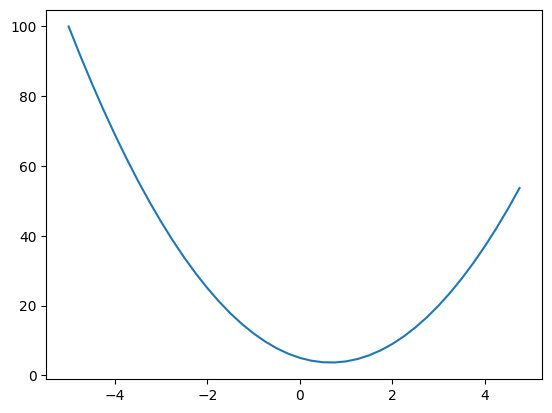

In [6]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [7]:
h = 0.000001
x = 2/3
(f(x + h) - f(x)) / h

2.999378523327323e-06

In [8]:
#les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [9]:
class Value:
    def __init__(self, data, children=(), op='', label = ''):
        self.data = data
        self.grad = 0.0 #zero means no effect
        self._prev = set(children)
        self._op = op
        self.label = label
        self._backward = lambda : None
    
    def __repr__(self):
        return f'Value(data={self.data}, label={self.label})'
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, children=(self, other), op='+')

        def  bc():
            self.grad += 1.0 * out.grad #+= multivariate case
            other.grad += 1.0 * out.grad

        out._backward = bc  
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, children=(self, other), op='*')

        def  bc():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = bc  
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int,float powers for now"
        out = Value(self.data ** other, (self, ), f'**{other}')

        def  bc():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = bc  
        return out
        
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rmul__(self, other): #other * self 2 * v
        return self * other
    
    def __truediv__(self, other): #self / other
        return self * (other ** -1)

    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def bc():
            self.grad += out.data * out.grad

        out._backward = bc
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
        out = Value(t, (self, ), 'tanh')

        def  bc():
            self.grad += (1 - t ** 2) * out.grad

        out._backward = bc
        return out
    
    def backward(self):
        topo = []
        vis = set()

        def build_topo(u):
            if u not in vis:
                vis.add(u)
                for i in u._prev:
                    build_topo(i)    
                topo.append(u)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [10]:
a = Value(2,  label="A")
b = Value(-3, label="B")
c = Value(10, label="C")
e = a * b; e.label = "E"
d = e + c
d.label = "D"
d._prev, d._op

({Value(data=-6, label=E), Value(data=10, label=C)}, '+')

In [11]:
def trace(root):
    nodes, edges = set(), set()

    def build(u):
        if u not in nodes:
            nodes.add(u)

            for i in u._prev:
                edges.add((i, u))
                build(i)

    build(root)

    return nodes, edges


In [12]:
from graphviz import Digraph

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #left to right

    nodes, edges = trace(root)

    for u in nodes:
        uid = str(id(u))

        #for any value / leaf node create a rectangular
        dot.node(name=uid, label='{%s | data %.4f | grad %.4f}' % (u.label, u.data, u.grad), shape='record')

        if u._op:
            # if this value is a result of some operation, create a op node for it
            dot.node(name=uid + u._op, label= u._op)

            #and connect this node to it
            dot.edge(uid + u._op, uid)

    for u, v in edges:
        #connect u to op node of v
        dot.edge(str(id(u)), str(id(v)) + v._op)

    return dot

In [13]:
f = Value(-2.0, label="F")
L = d * f
L.label = "loss"

In [14]:
L = d * f
#dL/dd = ?f
# (f(x + h) - f(x)) / h
# ((d + h) * f) - (d * f)) / h
#  (d *f + f*h - d* f) / h
# f

In [15]:
L.grad = 1.0
f.grad = 4.0 #value value of d
d.grad = -2.0 #value value of f

dl/dc crux , if we learn , then it covers most of NN

dd / dc ? 1.0

d = c + e

(f(x + h) - f(x)) / h

((c + e + h) - c - e) / h
1

dd / de = 1
we call them local derivative c, e, d

we are looking for dl/dc

WANT
dl/dc

WE KNOW
dl/dd
dd/dc

BY CHAIN RULE

dl/dc = dl/dd \* dd/dc

INTITUTION
Car run twice as fast bicycle and bicycle runs four times fast as a man, then cars runs eight times fast as man

dc/dm = dc/db \* db / dm


In [16]:
c.grad = -2.0
e.grad = -2.0

dl / da = dl/dd _ dd/de _ de/da
dl/dd = -2,
dd/de = 1
de/da = -3 // b


In [17]:
a.grad = 2 * 3
b.grad = -2 * 2

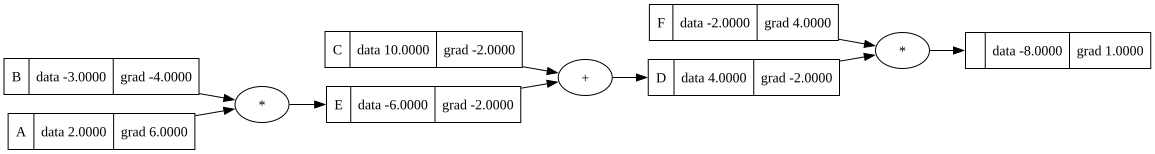

In [18]:
draw_dot(L)

In [19]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


In [20]:
def lol():
    h = 0.0001
    a = Value(2,  label="A")
    b = Value(-3, label="B")
    c = Value(10, label="C")
    e = a * b; e.label = "E"
    d = e + c
    d.label = "D"
    d._prev, d._op
    f = Value(-2.0, label="F")
    L = d * f
    L.label = "L"
    L1 = L.data

    #a = Value(2.0 + h,  label="A")
    a = Value(2.0,  label="A")

    b = Value(-3, label="B")
    b.data += h

    c = Value(10, label="C")
    e = a * b; e.label = "E"

    d = e + c
    d.label = "D"
    d._prev, d._op
    f = Value(-2.0, label="F")
    L = d * f
    L.label = "L"

    L2 = L.data

    print((L2 - L1) / h)
    #change l by h leads derivative dl/dl = 1

lol()

-4.000000000008441


In [21]:
#inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.88127, label='b')

#x1 * w1 + x2 * w2 + b
x1w1 = x1 * w1; x1w1.label = "x1*w1"
x2w2 = x2 * w2; x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


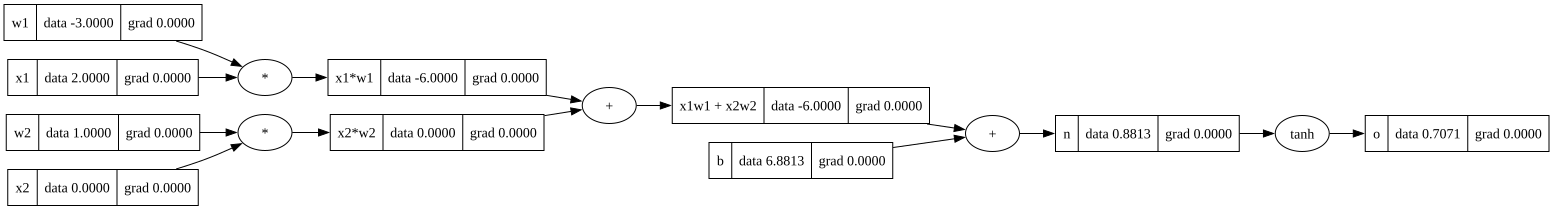

In [22]:
draw_dot(o)


In [23]:
"""o.grad = 1
n.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad


x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad"""


'o.grad = 1\nn.grad = 0.5\nb.grad = 0.5\nx1w1x2w2.grad = 0.5\nx1w1.grad = 0.5\nx2w2.grad = 0.5\n\nx2.grad = w2.data * x2w2.grad\nw2.grad = x2.data * x2w2.grad\n\n\nx1.grad = w1.data * x1w1.grad\nw1.grad = x1.data * x1w1.grad'

In [24]:
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [25]:
topo = []
vis = set()

def build_topo(u):
    if u not in vis:
        vis.add(u)
        for i in u._prev:
            build_topo(i)    
        topo.append(u)

build_topo(o)

o.grad = 1.0
#for node in reversed(topo):
#    node._backward()

In [26]:
o.backward() #now backward is part of Value class

In [27]:
#o = tanh(n)
#do/dn = 1 - tanh ** 2 or 1 - o ** 2 

1 - o.data ** 2


0.5000732497662675

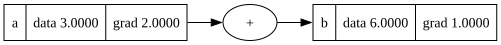

In [28]:
#Multivariate

a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

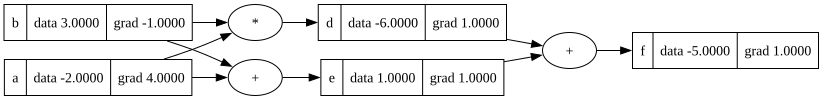

In [29]:
#Actual derivative of b should have been 2, , here we do self.grad += derivative rathet assigning only via =
a = Value(-2.0, label='a')
b = Value(3.0, label='b')

d = a * b; d.label ='d'
e = a + b; e.label = 'e'
f = d + e; f.label = 'f'

f.backward()
draw_dot(f)

#a.grad += d, e

In [30]:
a = Value(2.0)
a + 1
a * 2
3 * a
a.exp()
print(a)
a / 2
#a.backward()
a - b

Value(data=2.0, label=)


Value(data=-1.0, label=)

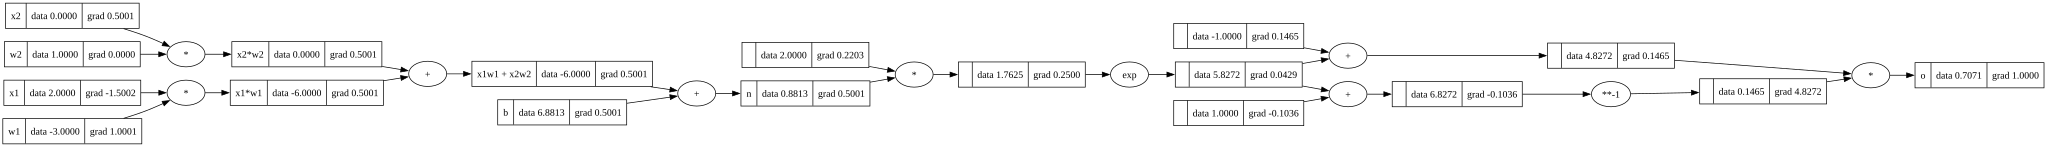

In [31]:
#inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.88127, label='b')

#x1 * w1 + x2 * w2 + b
x1w1 = x1 * w1; x1w1.label = "x1*w1"
x2w2 = x2 * w2; x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"

n = x1w1x2w2 + b; n.label = 'n'
#-- break tanh
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
#o = n.tanh(); o.label = 'o'
#-- break tanh
o.backward()
draw_dot(o)


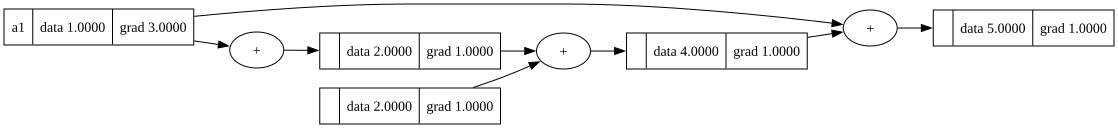

In [42]:
a1 = Value(1.0, label='a1')

for i in range(1):
    a1 += a1 + a1 +  2

a1.backward()
draw_dot(a1)

In [33]:
import torch
x1 = torch.tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.tensor([1.0]).double(); w2.requires_grad = True
b = torch.tensor([6.88137]).double(); b.requires_grad = True

n = w1 * x1 + w2 * x2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("----")
print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())



0.7071050214706146
----
x2 0.5000024886110417
w2 0.0
x1 -1.500007465833125
w1 1.0000049772220834


In [34]:
print(x2.grad.item())
o.item()


0.5000024886110417


0.7071050214706146